# Zhu-Net: обнаружение LSB-стеганографии (grayscale, 256×256)

## Конфигурация эксперимента

| Параметр | Значение |
|---|---|
| **Архитектура** | Zhu-Net (HPF → ResNeSt Split-Attention → GAP → FC) |
| **Входные данные** | Grayscale PNG, 256×256, 1 канал |
| **Датасет** | Cover=256, Stego=256 (итого 512 изображений) |
| **Разбиение** | 5-Fold Stratified Cross-Validation |
| **Train / Val** | 410 / 102 на фолд |
| **Метод встраивания** | LSB-replacement (1 бит, grayscale_dataset_LSB) |
| **Batch size** | 16 |
| **Learning rate** | 5e-4 (CosineAnnealingLR, eta_min=1e-5) |
| **Эпох на фолд** | 30 |
| **HPF warmup** | 5 эпох (заморожен после) |
| **Оптимизатор** | Adam, weight_decay=1e-4 |
| **Loss** | BCEWithLogitsLoss |
| **Grad clipping** | max_norm=1.0 |



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 1. Импорт библиотек
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)


In [3]:
# 2. Воспроизводимость и GPU
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')


Устройство: cuda


In [4]:
# 3. Конфигурация данных и папка сохранения
COVER_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset/'
STEGO_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset_LSB/'
IMG_SIZE  = 256

SAVE_DIR = '/content/drive/MyDrive/FQW/zhunet_grayscale_256'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Папка для сохранения: {SAVE_DIR}')

cover_imgs = sorted([
    os.path.join(COVER_DIR, f) for f in os.listdir(COVER_DIR)
    if f.lower().endswith('.png')
])
stego_imgs = sorted([
    os.path.join(STEGO_DIR, f) for f in os.listdir(STEGO_DIR)
    if f.lower().endswith('.png')
])

print(f'Cover: {len(cover_imgs)} | Stego: {len(stego_imgs)}')
assert len(cover_imgs) > 0 and len(stego_imgs) > 0, 'Изображения не найдены!'

# Глобальные списки — используются в skf.split() на каждой итерации CV
images = cover_imgs + stego_imgs
labels = [0] * len(cover_imgs) + [1] * len(stego_imgs)
print(f'Всего: {len(images)} изображений (Cover={labels.count(0)}, Stego={labels.count(1)})')


Папка для сохранения: /content/drive/MyDrive/FQW/zhunet_grayscale_256
Cover: 256 | Stego: 256
Всего: 512 изображений (Cover=256, Stego=256)


In [5]:
# 4. Dataset и DataLoader
class StegDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths, self.labels, self.augment = paths, labels, augment
        self.base_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
        ])

        self.train_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        # Grayscale → 'L', конвертируем в 1-канальный тензор
        img = Image.open(self.paths[idx]).convert('L')
        img = self.train_transform(img) if self.augment else self.base_transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

# Быстрая проверка
_ds = StegDataset(images[:2], labels[:2])
_x, _y = _ds[0]
print(f'Тензор: {_x.shape}, диапазон: [{_x.min():.3f}, {_x.max():.3f}], метка: {_y}')
assert _x.shape[0] == 1, 'Ожидается 1 канал (grayscale)!'


Тензор: torch.Size([1, 256, 256]), диапазон: [0.000, 0.000], метка: 0.0


In [6]:
# 5. Архитектура Zhu-Net для grayscale (1 входной канал)
#
# HPF (1→64, kernel=5, frozen) + BN + Tanh + Abs
# ResNeStBlock(64→64)              256×256
# ResNeStBlock(64→128,  stride=2)  128×128
# ResNeStBlock(128→256, stride=2)  64×64
# ResNeStBlock(256→512, stride=2)  32×32
# AdaptiveAvgPool → Dropout(0.3) → Linear(512,1)

def init_king_weights(layer):
    """Точный фильтр Кёнига 5×5 — без случайного шума.
    Нормировка: ker / sum(|ker|), чтобы сохранить high-pass свойство."""
    ker = np.array([
        [-1,  2, -2,  2, -1],
        [ 2, -6,  8, -6,  2],
        [-2,  8,-12,  8, -2],
        [ 2, -6,  8, -6,  2],
        [-1,  2, -2,  2, -1],
    ], dtype=np.float32)
    ker /= np.sum(np.abs(ker))  # нормировка по сумме абсолютных значений
    out_ch, in_ch = layer.out_channels, layer.in_channels
    w = np.zeros((out_ch, in_ch, 5, 5), dtype=np.float32)
    for i in range(out_ch):
        for c in range(in_ch):
            w[i, c] = ker
    layer.weight.data = torch.from_numpy(w).to(layer.weight.device)
    layer.weight.requires_grad = False  # заморожен по умолчанию


class RadixSoftmax(nn.Module):
    def __init__(self, radix, groups):
        super().__init__()
        self.radix, self.groups = radix, groups

    def forward(self, x):
        B = x.size(0)
        if self.radix > 1:
            x = x.view(B, self.groups, self.radix, -1)
            x = torch.softmax(x, dim=2)
            x = x.reshape(B, -1, 1, 1)
        else:
            x = torch.sigmoid(x.unsqueeze(2))
        return x


class SplitAttentionConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1,
                 padding=1, groups=1, radix=2, reduction_factor=4):
        super().__init__()
        self.radix, self.groups, self.out_ch = radix, groups, out_ch
        inter_ch = max(in_ch * radix // reduction_factor, 32)
        self.conv = nn.Conv2d(in_ch, out_ch * radix, kernel_size=kernel_size,
                              stride=stride, padding=padding, groups=groups, bias=False)
        self.bn0  = nn.BatchNorm2d(out_ch * radix)
        self.relu = nn.ReLU(inplace=True)
        self.fc1  = nn.Linear(out_ch, inter_ch)
        self.bn1  = nn.BatchNorm1d(inter_ch)
        self.fc2  = nn.Linear(inter_ch, out_ch * radix)
        self.rsoftmax = RadixSoftmax(radix, groups)

    def forward(self, x):
        x = self.relu(self.bn0(self.conv(x)))
        B, rC, H, W = x.shape
        splitted = torch.split(x, rC // self.radix, dim=1)
        gap = sum(splitted)
        gap = gap.mean(dim=[2, 3])
        gap = self.relu(self.bn1(self.fc1(gap)))
        atten = self.fc2(gap)
        atten = self.rsoftmax(atten)
        atten = torch.split(atten, self.out_ch, dim=1)
        out = sum(a * s for a, s in zip(atten, splitted))
        return out.contiguous()


class ResNeStBlock(nn.Module):
    expansion = 4

    def __init__(self, in_ch, out_ch, stride=1, radix=2, groups=1):
        super().__init__()
        mid_ch = out_ch // self.expansion if out_ch >= 64 else out_ch
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_ch)
        self.relu1 = nn.ReLU(inplace=True)
        self.sa    = SplitAttentionConv2d(mid_ch, mid_ch, 3, stride, 1, groups, radix)
        self.bn2   = nn.BatchNorm2d(mid_ch)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_ch)
        self.relu3 = nn.ReLU(inplace=True)
        if stride != 1 or in_ch != out_ch:
            sc = []
            if stride > 1:
                sc.append(nn.AvgPool2d(stride, stride, ceil_mode=True))
            sc += [nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch)]
            self.shortcut = nn.Sequential(*sc)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.sa(out)))
        out = self.bn3(self.conv3(out))
        return self.relu3(out + identity)


class ZhuNet(nn.Module):
    """Zhu-Net для grayscale изображений (1 входной канал).
    Выход: логит [B,1] для BCEWithLogitsLoss."""
    def __init__(self, in_channels=1, radix=2):
        super().__init__()
        # HPF: 1→64 каналов, grayscale
        self.hpf    = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2, bias=False)
        self.hpf_bn = nn.BatchNorm2d(64)
        init_king_weights(self.hpf)

        self.layer1 = ResNeStBlock(64,  64,  stride=1, radix=radix)
        self.layer2 = ResNeStBlock(64,  128, stride=2, radix=radix)
        self.layer3 = ResNeStBlock(128, 256, stride=2, radix=radix)
        self.layer4 = ResNeStBlock(256, 512, stride=2, radix=radix)

        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(512, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) and m is not self.hpf:
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.hpf_bn(self.hpf(x))
        x = torch.abs(torch.tanh(x))   # Tanh+Abs: усиливает оба знака LSB-следа
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)  # [B,1]


# Проверка
_model = ZhuNet(in_channels=1).to(device)
total  = sum(p.numel() for p in _model.parameters())
frozen = sum(p.numel() for p in _model.parameters() if not p.requires_grad)
print(f'Параметров всего:   {total:,}')
print(f'Заморожено (HPF):   {frozen:,}')
print(f'Обучаемых:          {total-frozen:,}')
with torch.no_grad():
    _out = _model(torch.randn(2, 1, 256, 256).to(device))
print(f'Форма выхода: {_out.shape}  (ожидается [2, 1])')
print(f'NaN в выходе: {torch.isnan(_out).any().item()}')
del _model, _out


Параметров всего:   738,945
Заморожено (HPF):   1,600
Обучаемых:          737,345
Форма выхода: torch.Size([2, 1])  (ожидается [2, 1])
NaN в выходе: False


In [7]:
# 6. Обучение: 5-Fold Cross-Validation

BATCH_SIZE             = 16
LEARNING_RATE          = 5e-4
EPOCHS                 = 30
UNFREEZE_EPOCHS_FOR_CV = 5
N_FOLDS                = 5

print('\n' + '='*60)
print(' ЗАПУСК 5-FOLD CROSS-VALIDATION для ZhuNet (grayscale 256)')
print('='*60)
print(f'Датасет: {len(images)} изображений | Эпох: {EPOCHS} | LR: {LEARNING_RATE}')
print(f'Сохранение: {SAVE_DIR}')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = {
    'auc':[], 'accuracy':[], 'precision_cover':[], 'precision_stego':[],
    'recall_cover':[], 'recall_stego':[], 'f1_cover':[], 'f1_stego':[],
}
all_fold_probs, all_fold_labels_list, all_fold_histories = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(images, labels)):
    print(f"\n{'='*60}\n FOLD {fold+1}/{N_FOLDS}\n{'='*60}")

    X_train_fold = [images[i] for i in train_idx]
    y_train_fold = [labels[i] for i in train_idx]
    X_val_fold   = [images[i] for i in val_idx]
    y_val_fold   = [labels[i] for i in val_idx]
    print(f'Train: {len(X_train_fold)} | Val: {len(X_val_fold)}')
    print(f'Train: Cover={y_train_fold.count(0)}, Stego={y_train_fold.count(1)}')

    train_ds = StegDataset(X_train_fold, y_train_fold, augment=True)
    val_ds   = StegDataset(X_val_fold,   y_val_fold,   augment=False)
    train_loader_fold = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader_fold   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model     = ZhuNet(in_channels=1, radix=2).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    best_auc, best_model_state, best_threshold = 0.0, None, 0.5
    fold_history = {'loss':[], 'val_acc':[], 'val_auc':[]}

    for epoch in range(EPOCHS):
        # HPF warmup: первые 5 эпох HPF адаптируется, затем замораживается
        model.hpf.weight.requires_grad = (epoch < UNFREEZE_EPOCHS_FOR_CV)

        # TRAIN
        model.train()
        running_loss = 0.0
        # batch_labels — локальная переменная батча.
        for inputs, batch_labels in train_loader_fold:
            inputs       = inputs.to(device)
            batch_labels = batch_labels.to(device).unsqueeze(1).float()
            optimizer.zero_grad()
            loss = criterion(model(inputs), batch_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader_fold)
        scheduler.step()

        # VAL
        model.eval()
        vl, vp, vla = [], [], []
        with torch.no_grad():
            for inputs, batch_labels in val_loader_fold:
                probs = torch.sigmoid(model(inputs.to(device))).cpu().numpy()
                vp.extend(probs); vla.extend(batch_labels.numpy())
                vl.extend((probs > 0.5).astype(int))

        auc  = roc_auc_score(vla, vp)
        acc  = accuracy_score(vla, vl)
        fold_history['loss'].append(avg_loss)
        fold_history['val_acc'].append(acc)
        fold_history['val_auc'].append(auc)

        if (epoch+1) % 5 == 0 or epoch == 0:
            hpf = 'разморожен' if epoch < UNFREEZE_EPOCHS_FOR_CV else 'заморожен'
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
                  f'Acc: {acc:.4f} | AUC: {auc:.4f} | HPF: {hpf}')

        if auc > best_auc:
            best_auc = auc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            fpr_t, tpr_t, thr_t = roc_curve(vla, vp)
            best_threshold = float(thr_t[np.argmax(tpr_t - fpr_t)])

    all_fold_histories.append(fold_history)

    vla_np = np.array(vla).flatten()
    vp_np  = np.array(vp).flatten()
    preds  = (vp_np > best_threshold).astype(int)

    fold_metrics['auc'].append(best_auc)
    fold_metrics['accuracy'].append(accuracy_score(vla_np, preds))
    fold_metrics['precision_cover'].append(precision_score(vla_np, preds, pos_label=0, zero_division=0))
    fold_metrics['precision_stego'].append(precision_score(vla_np, preds, pos_label=1, zero_division=0))
    fold_metrics['recall_cover'].append(recall_score(vla_np, preds, pos_label=0, zero_division=0))
    fold_metrics['recall_stego'].append(recall_score(vla_np, preds, pos_label=1, zero_division=0))
    fold_metrics['f1_cover'].append(f1_score(vla_np, preds, pos_label=0, zero_division=0))
    fold_metrics['f1_stego'].append(f1_score(vla_np, preds, pos_label=1, zero_division=0))
    all_fold_probs.extend(vp_np.tolist())
    all_fold_labels_list.extend(vla_np.tolist())

    print(f'\n  Fold {fold+1} — лучший AUC: {best_auc:.4f} | Порог: {best_threshold:.4f}')

    # Сохранение: float()
    torch.save({
        'fold': fold+1,
        'model_state_dict': best_model_state,
        'best_auc':          float(best_auc),
        'optimal_threshold': float(best_threshold),
        'fold_history':      fold_history,
    }, os.path.join(SAVE_DIR, f'zhunet_gs256_fold_{fold+1}.pth'))

# Сохранение промежуточных результатов
cv_data = {
    'model': 'ZhuNet grayscale 256x256',
    'n_folds': N_FOLDS,
    'fold_results': [
        {
            'fold': i+1,
            'auc':              float(fold_metrics['auc'][i]),
            'accuracy':         float(fold_metrics['accuracy'][i]),
            'f1_cover':         float(fold_metrics['f1_cover'][i]),
            'f1_stego':         float(fold_metrics['f1_stego'][i]),
            'precision_cover':  float(fold_metrics['precision_cover'][i]),
            'precision_stego':  float(fold_metrics['precision_stego'][i]),
            'recall_cover':     float(fold_metrics['recall_cover'][i]),
            'recall_stego':     float(fold_metrics['recall_stego'][i]),
            'optimal_threshold_at_best_auc': float(
                # weights_only=False — необходимо для PyTorch >= 2.6
                torch.load(os.path.join(SAVE_DIR, f'zhunet_gs256_fold_{i+1}.pth'),
                           weights_only=False)['optimal_threshold']
            ),
        } for i in range(N_FOLDS)
    ],
    'aggregated_probs_and_labels': {
        'probs':  all_fold_probs,
        'labels': all_fold_labels_list,
    }
}
with open(os.path.join(SAVE_DIR, 'zhunet_gs256_training_results.json'), 'w') as f:
    json.dump(cv_data, f, indent=2)
print(f'\nРезультаты сохранены: {SAVE_DIR}')



 ЗАПУСК 5-FOLD CROSS-VALIDATION для ZhuNet (grayscale 256)
Датасет: 512 изображений | Эпох: 30 | LR: 0.0005
Сохранение: /content/drive/MyDrive/FQW/zhunet_grayscale_256

 FOLD 1/5
Train: 409 | Val: 103
Train: Cover=204, Stego=205
  Epoch  1/30 | Loss: 0.3355 | Acc: 0.5049 | AUC: 0.4887 | HPF: разморожен
  Epoch  5/30 | Loss: 0.4587 | Acc: 0.4757 | AUC: 0.4683 | HPF: разморожен
  Epoch 10/30 | Loss: 0.0050 | Acc: 0.9903 | AUC: 1.0000 | HPF: заморожен
  Epoch 15/30 | Loss: 0.0004 | Acc: 1.0000 | AUC: 1.0000 | HPF: заморожен
  Epoch 20/30 | Loss: 0.0008 | Acc: 1.0000 | AUC: 1.0000 | HPF: заморожен
  Epoch 25/30 | Loss: 0.0016 | Acc: 1.0000 | AUC: 1.0000 | HPF: заморожен
  Epoch 30/30 | Loss: 0.0000 | Acc: 1.0000 | AUC: 1.0000 | HPF: заморожен

  Fold 1 — лучший AUC: 1.0000 | Порог: 0.9707

 FOLD 2/5
Train: 409 | Val: 103
Train: Cover=205, Stego=204
  Epoch  1/30 | Loss: 0.3076 | Acc: 0.4951 | AUC: 0.4555 | HPF: разморожен
  Epoch  5/30 | Loss: 0.2301 | Acc: 0.5146 | AUC: 0.4035 | HPF: раз


 АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — ZhuNet grayscale 256
AUC                   : 1.0000 ± 0.0000  [min=1.0000, max=1.0000]
ACCURACY              : 0.9000 ± 0.2000  [min=0.5000, max=1.0000]
F1_COVER              : 0.9333 ± 0.1333  [min=0.6667, max=1.0000]
F1_STEGO              : 0.8000 ± 0.4000  [min=0.0000, max=1.0000]
PRECISION_COVER       : 0.9000 ± 0.2000  [min=0.5000, max=1.0000]
PRECISION_STEGO       : 0.8000 ± 0.4000  [min=0.0000, max=1.0000]
RECALL_COVER          : 1.0000 ± 0.0000  [min=1.0000, max=1.0000]
RECALL_STEGO          : 0.8000 ± 0.4000  [min=0.0000, max=1.0000]

AUC на случайных лейблах (проверка утечки): 0.5092

Оптимальный порог: 1.0000

Classification Report:
              precision    recall  f1-score   support

       Cover       1.00      1.00      1.00       256
       Stego       1.00      1.00      1.00       256

    accuracy                           1.00       512
   macro avg       1.00      1.00      1.00       512
weighted avg       1.00      1.00   

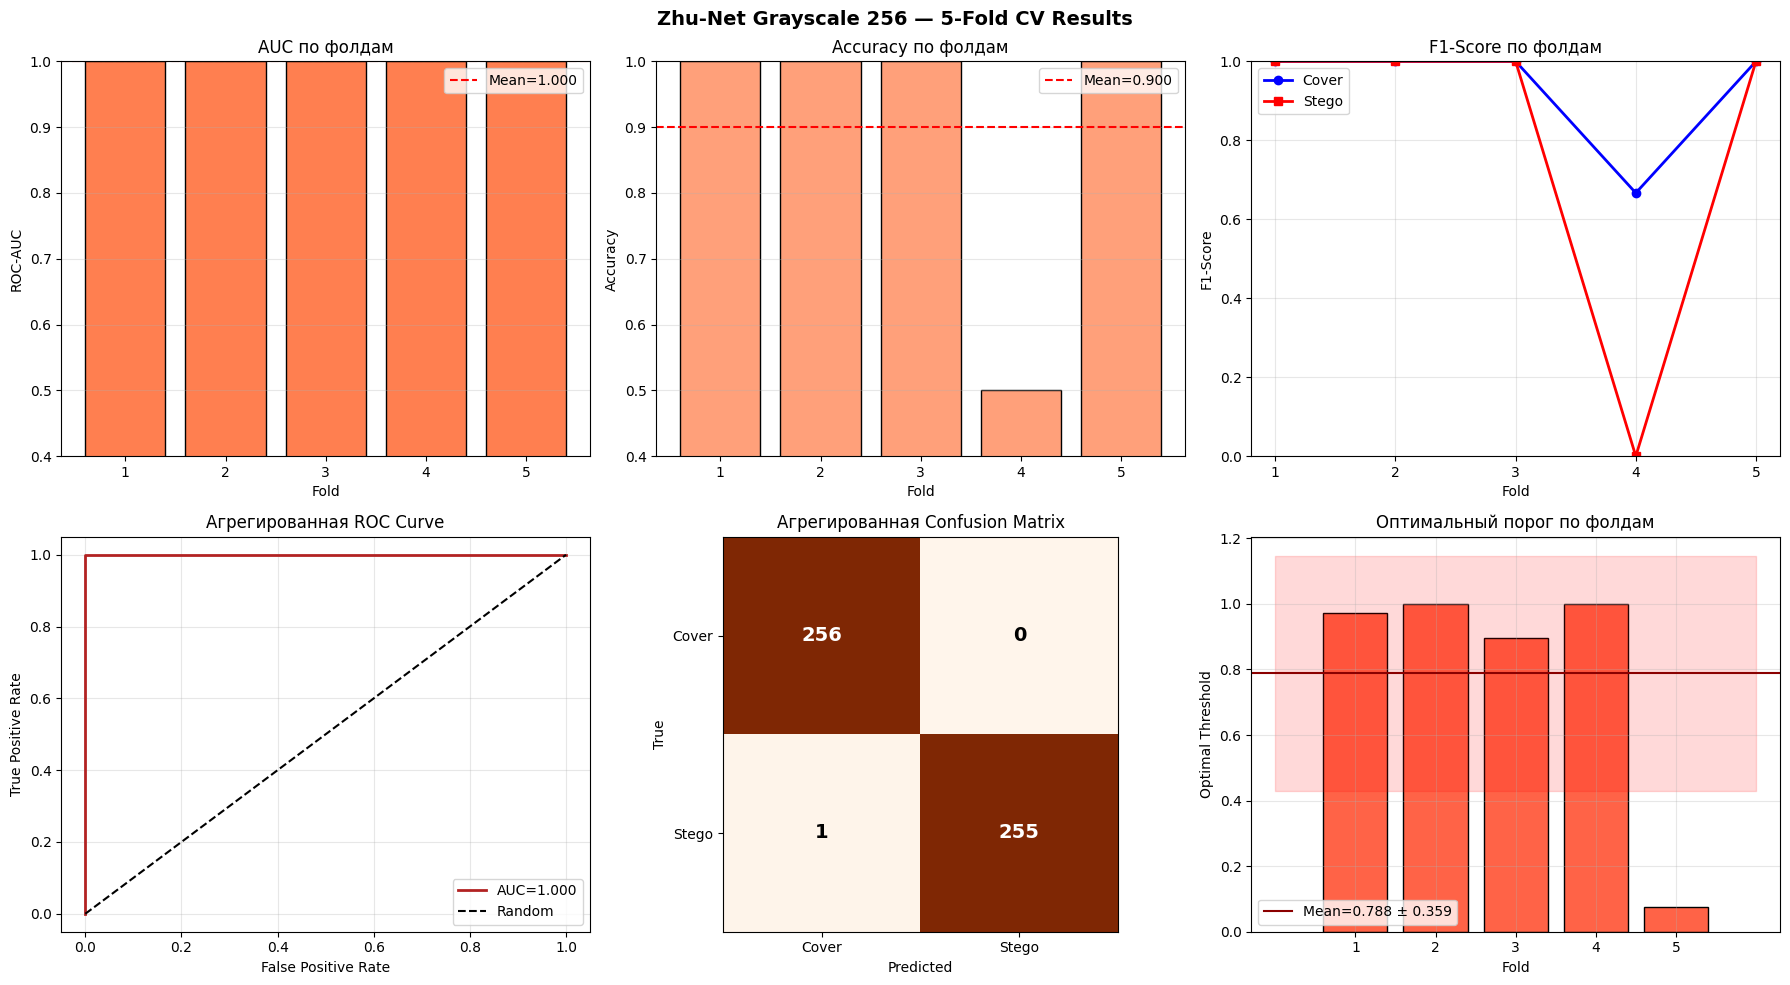

График сохранён: /content/drive/MyDrive/FQW/zhunet_grayscale_256/zhunet_gs256_results.png
Финальные результаты сохранены: /content/drive/MyDrive/FQW/zhunet_grayscale_256/zhunet_gs256_final_results.json


In [8]:
# 7. Агрегация результатов и визуализация

with open(os.path.join(SAVE_DIR, 'zhunet_gs256_training_results.json'), 'r') as f:
    cv_data = json.load(f)

fold_metrics = {
    key: [res[key] for res in cv_data['fold_results']]
    for key in cv_data['fold_results'][0]
    if key not in ['fold', 'optimal_threshold_at_best_auc']
}
all_fold_probs_np  = np.array(cv_data['aggregated_probs_and_labels']['probs'])
all_fold_labels_np = np.array(cv_data['aggregated_probs_and_labels']['labels'])

print('\n' + '='*60)
print(' АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — ZhuNet grayscale 256')
print('='*60)
for m in ['auc','accuracy','f1_cover','f1_stego',
          'precision_cover','precision_stego','recall_cover','recall_stego']:
    v = fold_metrics[m]
    print(f'{m.upper():<22s}: {np.mean(v):.4f} ± {np.std(v):.4f}  '
          f'[min={np.min(v):.4f}, max={np.max(v):.4f}]')

# Проверка утечки данных
auc_random = roc_auc_score(np.random.permutation(all_fold_labels_np), all_fold_probs_np)
print(f'\nAUC на случайных лейблах (проверка утечки): {auc_random:.4f}')

# Оптимальный порог
fpr_agg, tpr_agg, thr_agg = roc_curve(all_fold_labels_np, all_fold_probs_np)
opt_thr = float(thr_agg[np.argmax(tpr_agg - fpr_agg)])
final_preds = (all_fold_probs_np > opt_thr).astype(int)
print(f'\nОптимальный порог: {opt_thr:.4f}')
print('\nClassification Report:')
print(classification_report(all_fold_labels_np, final_preds,
                            target_names=['Cover','Stego'], zero_division=0))
cm = confusion_matrix(all_fold_labels_np, final_preds)
print('Confusion Matrix:')
print(cm)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Zhu-Net Grayscale 256 — 5-Fold CV Results', fontsize=14, fontweight='bold')

# 1. AUC по фолдам
axes[0,0].bar(range(1, N_FOLDS+1), fold_metrics['auc'], color='coral', edgecolor='black')
axes[0,0].axhline(np.mean(fold_metrics['auc']), color='red', linestyle='--',
                  label=f'Mean={np.mean(fold_metrics["auc"]):.3f}')
axes[0,0].set_xlabel('Fold'); axes[0,0].set_ylabel('ROC-AUC')
axes[0,0].set_title('AUC по фолдам'); axes[0,0].set_xticks(range(1, N_FOLDS+1))
axes[0,0].legend(); axes[0,0].grid(axis='y', alpha=0.3); axes[0,0].set_ylim([0.4, 1.0])

# 2. Accuracy по фолдам
axes[0,1].bar(range(1, N_FOLDS+1), fold_metrics['accuracy'], color='lightsalmon', edgecolor='black')
axes[0,1].axhline(np.mean(fold_metrics['accuracy']), color='red', linestyle='--',
                  label=f'Mean={np.mean(fold_metrics["accuracy"]):.3f}')
axes[0,1].set_xlabel('Fold'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Accuracy по фолдам'); axes[0,1].set_xticks(range(1, N_FOLDS+1))
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.3); axes[0,1].set_ylim([0.4, 1.0])

# 3. F1-Score по фолдам
axes[0,2].plot(range(1, N_FOLDS+1), fold_metrics['f1_cover'], 'b-o', label='Cover', linewidth=2)
axes[0,2].plot(range(1, N_FOLDS+1), fold_metrics['f1_stego'], 'r-s', label='Stego', linewidth=2)
axes[0,2].set_xlabel('Fold'); axes[0,2].set_ylabel('F1-Score')
axes[0,2].set_title('F1-Score по фолдам'); axes[0,2].set_xticks(range(1, N_FOLDS+1))
axes[0,2].legend(); axes[0,2].grid(alpha=0.3); axes[0,2].set_ylim([0.0, 1.0])

# 4. Агрегированная ROC-кривая
overall_auc = roc_auc_score(all_fold_labels_np, all_fold_probs_np)
axes[1,0].plot(fpr_agg, tpr_agg, color='firebrick', linewidth=2, label=f'AUC={overall_auc:.3f}')
axes[1,0].plot([0,1],[0,1],'k--', label='Random')
axes[1,0].set_xlabel('False Positive Rate'); axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('Агрегированная ROC Curve')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# 5. Confusion Matrix
im = axes[1,1].imshow(cm, interpolation='nearest', cmap='Oranges')
axes[1,1].set_title('Агрегированная Confusion Matrix')
axes[1,1].set_xlabel('Predicted'); axes[1,1].set_ylabel('True')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(['Cover','Stego'])
axes[1,1].set_yticks([0,1]); axes[1,1].set_yticklabels(['Cover','Stego'])
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, str(cm[i,j]), ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

# 6. Оптимальные пороги по фолдам
thr_per_fold = [res['optimal_threshold_at_best_auc'] for res in cv_data['fold_results']]
mt, st = np.mean(thr_per_fold), np.std(thr_per_fold)
axes[1,2].bar(range(1, N_FOLDS+1), thr_per_fold, color='tomato', edgecolor='black')
axes[1,2].axhline(mt, color='darkred', label=f'Mean={mt:.3f} ± {st:.3f}')
axes[1,2].fill_between(range(0, N_FOLDS+2), mt-st, mt+st, color='red', alpha=0.15)
axes[1,2].set_xlabel('Fold'); axes[1,2].set_ylabel('Optimal Threshold')
axes[1,2].set_title('Оптимальный порог по фолдам')
axes[1,2].set_xticks(range(1, N_FOLDS+1))
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
png_path = os.path.join(SAVE_DIR, 'zhunet_gs256_results.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'График сохранён: {png_path}')

# Финальный JSON
final = {
    'model': cv_data['model'],
    'metrics': {
        'auc_mean':      float(np.mean(fold_metrics['auc'])),
        'auc_std':       float(np.std(fold_metrics['auc'])),
        'accuracy_mean': float(np.mean(fold_metrics['accuracy'])),
        'accuracy_std':  float(np.std(fold_metrics['accuracy'])),
        'f1_cover_mean': float(np.mean(fold_metrics['f1_cover'])),
        'f1_stego_mean': float(np.mean(fold_metrics['f1_stego'])),
    },
    'aggregated': {
        'overall_auc':               float(overall_auc),
        'overall_accuracy':          float(accuracy_score(all_fold_labels_np, final_preds)),
        'overall_optimal_threshold': float(opt_thr),
        'confusion_matrix':          cm.tolist(),
    }
}
with open(os.path.join(SAVE_DIR, 'zhunet_gs256_final_results.json'), 'w') as f:
    json.dump(final, f, indent=2)
print(f'Финальные результаты сохранены: {SAVE_DIR}/zhunet_gs256_final_results.json')
